<h2 align="center">Superstore Sales Analysis</h2>

## Objective

The objective of this project is to analyze sales performance across different regions, categories, products, and time periods. The analysis aims to identify sales trends, profitable and loss-making products, seasonal patterns, and provide actionable business recommendations for Alfido Tech.

<h3>Importing Libraries</h3>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df=pd.read_csv("sample - superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

<h3>Summary Statistics</h3>

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.median(numeric_only=True)

Row ID          4997.5000
Postal Code    56430.5000
Sales             54.4900
Quantity           3.0000
Discount           0.2000
Profit             8.6665
dtype: float64

In [10]:
df.mode().iloc[0]

Row ID                         1
Order ID          CA-2017-100111
Order Date              9/5/2016
Ship Date             12/16/2015
Ship Mode         Standard Class
Customer ID             WB-21850
Customer Name      William Brown
Segment                 Consumer
Country            United States
City               New York City
State                 California
Postal Code              10035.0
Region                      West
Product ID       OFF-PA-10001970
Category         Office Supplies
Sub-Category             Binders
Product Name     Staple envelope
Sales                      12.96
Quantity                     3.0
Discount                     0.0
Profit                       0.0
Name: 0, dtype: object

<h3>Cleaning Dataset</h3>

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

<h3>Feature Engineering</h3>

In [16]:
df['Year'] = df['Order Date'].dt.year

In [17]:
df['Month'] = df['Order Date'].dt.month_name()

In [18]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [19]:
#shipping days
df['Shipping Days']=(df['Ship Date']-df['Order Date']).dt.days

<h3>KPI Analysis</h3>

In [20]:
#Total Revenue
total_revenue=df['Sales'].sum()

print("Total Revenue:",round(total_revenue,2))

Total Revenue: 2297200.86


In [21]:
#Total Profit
total_profit=df['Profit'].sum()

print("Total Profit:",round(total_profit,2))

Total Profit: 286397.02


In [22]:
#Profit Margin
profit_margin=(total_profit/total_revenue)*100

print("Profit Margin:",round(profit_margin,2),"%")

Profit Margin: 12.47 %


In [23]:
#Average Order Value
average_order_value=df['Sales'].sum()/df['Order ID'].nunique()

print("Average Order Value:",round(average_order_value,2))

Average Order Value: 458.61


In [24]:
#Total Orders
total_orders=df['Order ID'].nunique()

print("Total Orders:",total_orders)

Total Orders: 5009


In [25]:
# Average Shipping Days
avg_shipping=df['Shipping Days'].mean()

print("Average Shipping Days:",round(avg_shipping,2))

Average Shipping Days: 3.96


<h3>Visualization</h3>

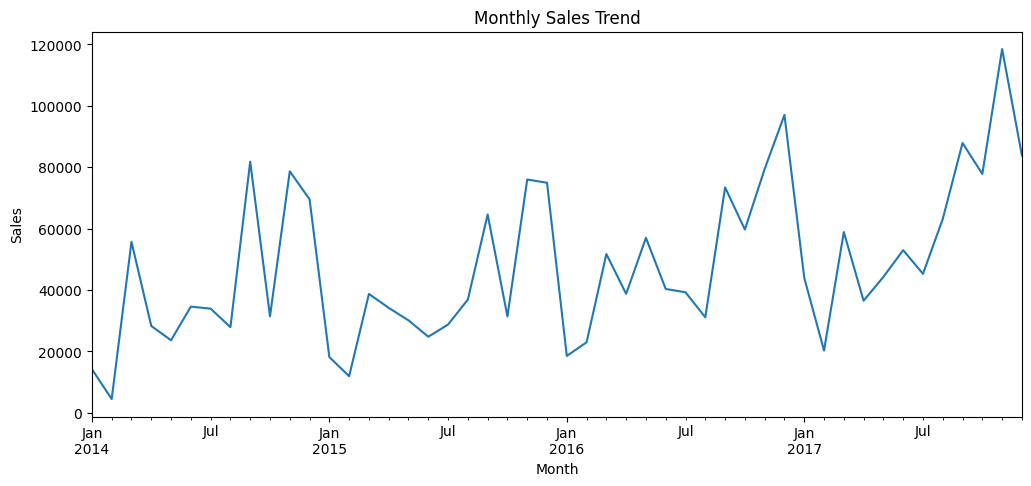

In [26]:
#Sales Trend Analysis

monthly_sales=df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("sales_trend.png",dpi=300,bbox_inches="tight")

plt.show()

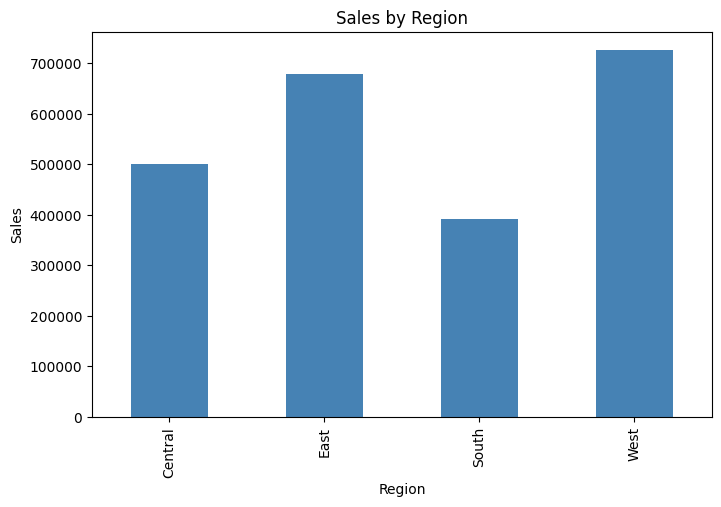

In [27]:
#Regional Performance

region_sales=df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar',color='steelblue')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.savefig("region_sales.png",dpi=300,bbox_inches="tight")

plt.show()

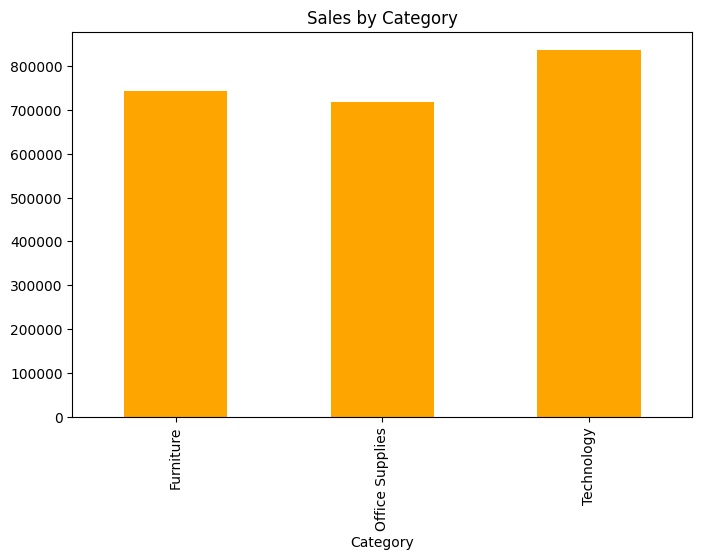

In [28]:
#Category Performance

category_sales=df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar',color='orange')

plt.title("Sales by Category")

plt.savefig("category_sales.png",dpi=300,bbox_inches="tight")

plt.show()

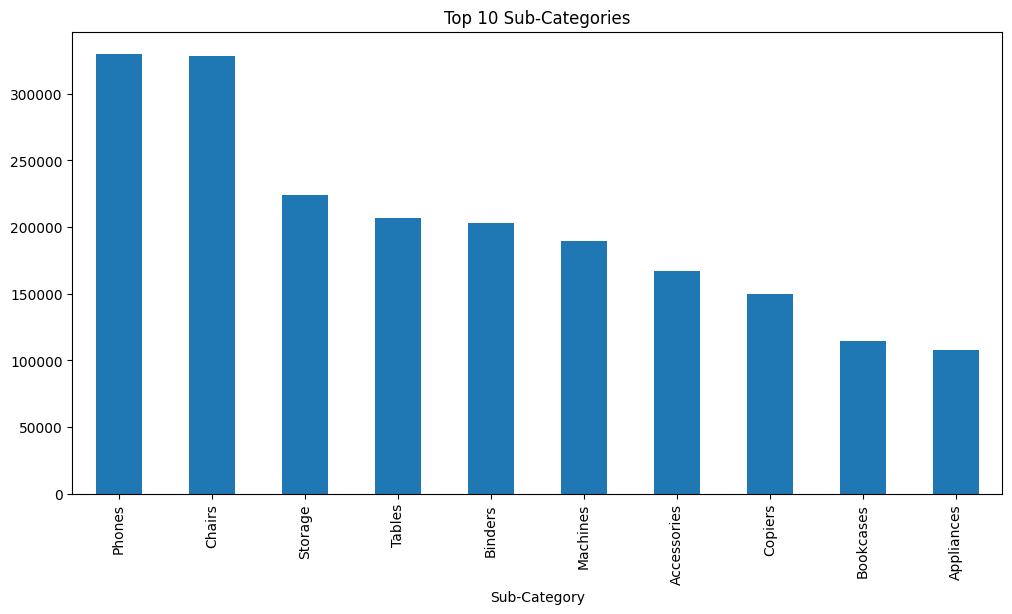

In [29]:
#SubCategory Performance

subcategory=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

subcategory.head(10).plot(kind='bar')

plt.title("Top 10 Sub-Categories")

plt.savefig("subcategory.png",dpi=300,bbox_inches="tight")

plt.show()

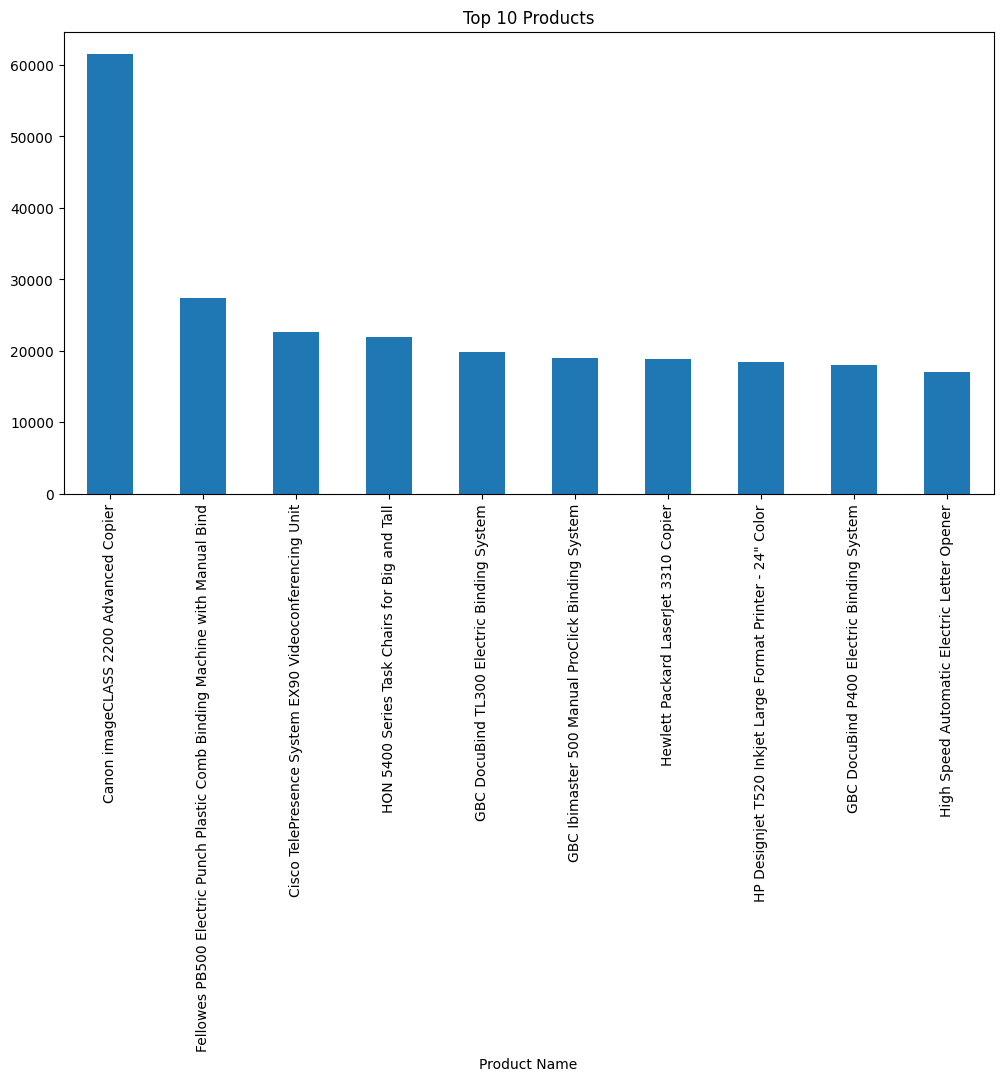

In [30]:
#Top 10 Products

top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Products")

plt.savefig("top_products.png",dpi=300,bbox_inches="tight")

plt.show()

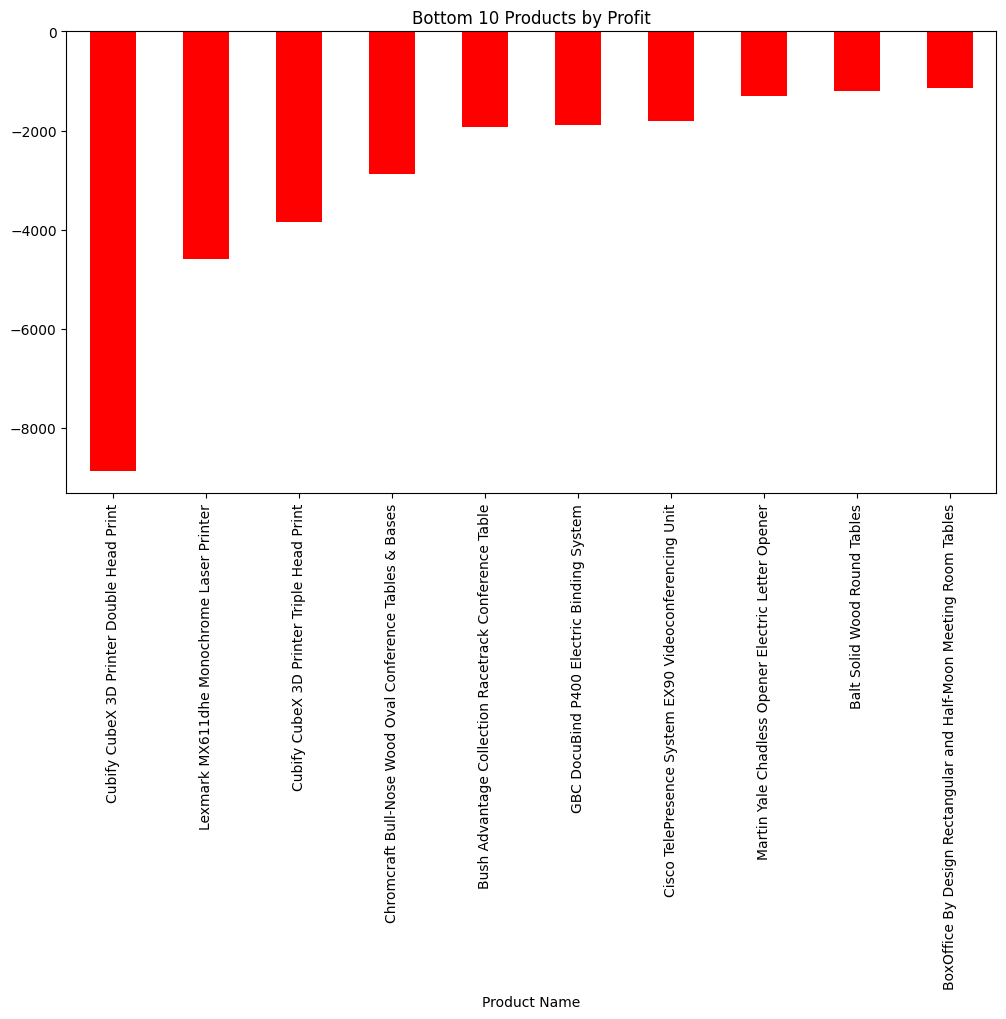

In [31]:
#Worst Products (Loss Making)

worst_products=df.groupby('Product Name')['Profit'].sum().sort_values()

plt.figure(figsize=(12,6))

worst_products.head(10).plot(kind='bar',color='red')

plt.title("Bottom 10 Products by Profit")

plt.savefig("worst_products.png",dpi=300,bbox_inches="tight")

plt.show()

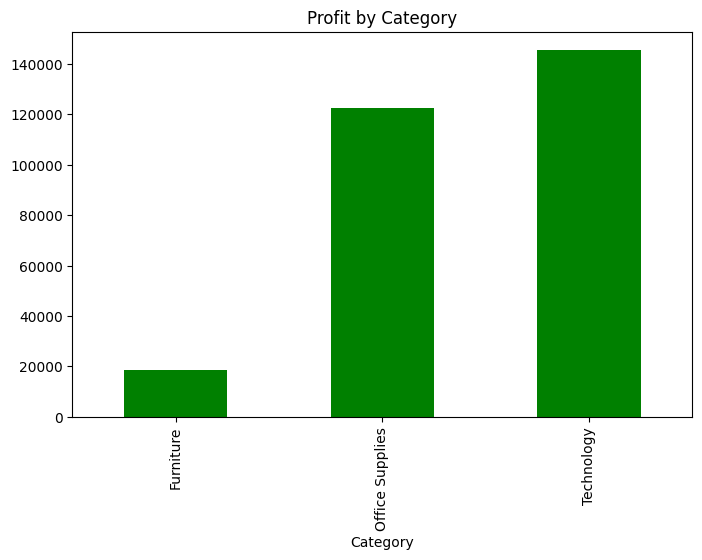

In [32]:
#Profit by Category

profit=df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))

profit.plot(kind='bar',color='green')

plt.title("Profit by Category")

plt.savefig("profit_category.png",dpi=300,bbox_inches="tight")

plt.show()

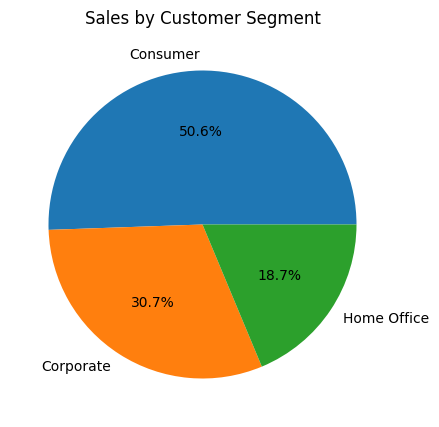

In [33]:
#Sales by Segment

segment=df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,5))

segment.plot(kind='pie',autopct='%1.1f%%')

plt.ylabel("")

plt.title("Sales by Customer Segment")

plt.savefig("segment_sales.png",dpi=300,bbox_inches="tight")

plt.show()

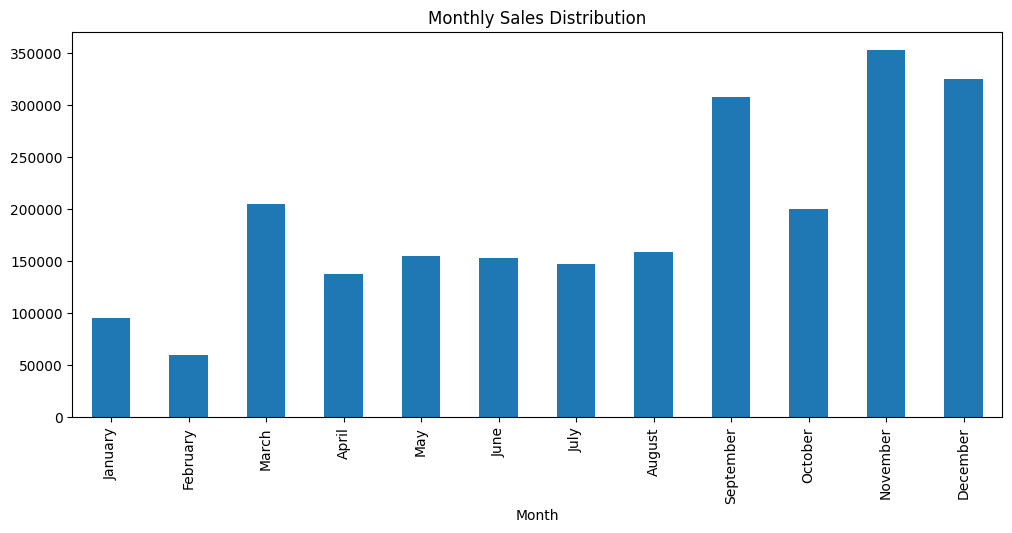

In [34]:
#Monthly Sales Distribution (Seasonality)

months=["January","February","March","April","May","June","July","August","September","October","November","December"]

monthly=df.groupby('Month')['Sales'].sum().reindex(months)

plt.figure(figsize=(12,5))

monthly.plot(kind='bar')

plt.title("Monthly Sales Distribution")

plt.savefig("seasonality.png",dpi=300,bbox_inches="tight")

plt.show()

In [35]:
print("Key Business Insights\n")

print("1. The highest-performing region generated the maximum sales and should be prioritized for future expansion.")

print("2. Technology and Office Supplies contributed significantly to overall revenue and profitability.")

print("3. A small number of products generated the majority of sales, indicating opportunities for focused inventory planning.")

print("4. Several products consistently generated losses despite recording sales, suggesting the need for pricing or cost optimization.")

print("5. Sales varied across months, highlighting seasonal demand patterns that can guide promotional campaigns.")

print("6. Consumer and Corporate segments contributed the largest share of revenue.")

print("7. Average order value indicates healthy purchasing behavior and can be improved through product bundling strategies.")

Key Business Insights

1. The highest-performing region generated the maximum sales and should be prioritized for future expansion.
2. Technology and Office Supplies contributed significantly to overall revenue and profitability.
3. A small number of products generated the majority of sales, indicating opportunities for focused inventory planning.
4. Several products consistently generated losses despite recording sales, suggesting the need for pricing or cost optimization.
5. Sales varied across months, highlighting seasonal demand patterns that can guide promotional campaigns.
6. Consumer and Corporate segments contributed the largest share of revenue.
7. Average order value indicates healthy purchasing behavior and can be improved through product bundling strategies.


In [36]:
print("Recommendations for Alfido Tech\n")

print("1. Increase inventory and marketing investment for best-selling products.")

print("2. Review pricing, discounts, and supplier costs for loss-making products.")

print("3. Focus promotional campaigns on high-performing regions while improving performance in weaker regions.")

print("4. Launch seasonal sales campaigns during historically high-demand months.")

print("5. Introduce product bundles and cross-selling strategies to increase average order value.")

Recommendations for Alfido Tech

1. Increase inventory and marketing investment for best-selling products.
2. Review pricing, discounts, and supplier costs for loss-making products.
3. Focus promotional campaigns on high-performing regions while improving performance in weaker regions.
4. Launch seasonal sales campaigns during historically high-demand months.
5. Introduce product bundles and cross-selling strategies to increase average order value.


## Conclusion

This project analyzed Superstore sales performance across products, categories, regions, and time. The findings identified top-performing products, loss-making products, regional sales differences, and seasonal trends. The insights and recommendations can help Alfido Tech optimize inventory management, improve profitability, strengthen regional sales strategies, and increase customer value.